In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import itertools
from sklearn.manifold import MDS

from Clustering_Functions import *

In [2]:
def Candidate_dist_matrix(election, num_cands = 'Auto', method = 'mean_borda', trunc = None):
    """ 
    Returns a symmetric matrix whose (i,j) entry is one of these measurements of their 'distance':
    method = 'successive': the reciprocal of the number of ballots on which candidates i & j appear next to each other.
    method = 'coappearances': the reciprocal of the number of ballots on which candidates i & j both appear.
    method = 'borda' : the average diference in borda_avg points that ballots award to candidates i & j
    method = 'mean_borda' : the average over the completions of the ballots of the diference in the borda points awarded to candidates i & j

    Args
        election : dictionary matching ballots to weights
        num_cands : the number of candidates.  Set to 'Auto' to ask the algorithm to determine it.
        method : one of {'successive', 'coappearances'}
        trunc : truncate all ballots at this position before applying the method.
    """
    if num_cands == 'Auto':
        num_cands = max([item for ranking in election.keys() for item in ranking])
    
    M = np.zeros([num_cands,num_cands])
    if trunc == None:
        trunc = num_cands

    if method == 'successive':
        for ballot, weight in election.items():
            for ballot_position in range(min(len(ballot),trunc)-1):
                c1 = ballot[ballot_position]-1
                c2 = ballot[ballot_position+1]-1
                M[c1,c2] += weight
                M[c2,c1] += weight
    elif method == 'coappearances':
        for ballot,weight in election.items():
            trunc_ballot = ballot[:trunc]
            for a,b in itertools.combinations(trunc_ballot,2):
                M[a-1,b-1] +=weight
                M[b-1,a-1] +=weight
    elif method == 'borda' or method == 'mean_borda':
        for ballot, weight in election.items():
            trunc_ballot = ballot[:trunc]
            num_missing = num_cands - len(ballot)
            v = Borda_vector(ballot, num_cands=num_cands, borda_style='full_points')
            for i in range(num_cands):
                for j in range(num_cands):
                    M[i,j] += np.abs(v[i]-v[j])*weight
                    if method == 'mean_borda' and v[i]==v[j]:
                        M[i,j] += (num_missing+1/3)*weight
    else:
        raise Exception("method must be one of {'successive', 'coappearances', 'borda', 'mean_borda'.")
    
    #if not penalty == None:
    #    on_cands = set(ballot)
    #    off_cands = set(range(1,num_cands+1))-on_cands
    #    for c1 in on_cands:
    #        for c2 in off_cands:
    #            M[c1-1,c2-1] -= weight*penalty
    #            M[c2-1,c1-1] -= weight*penalty
    if method == 'coappearances' or method == 'successive':
        # return the component-wise reciprical of the matrix
        for i in range(num_cands):
            for j in  range(num_cands):
                if i==j:
                    M[i,j]=0
                else:
                    M[i,j]=1/M[i,j]     
    return M

In [3]:
def Candidate_MDS_plot(election, method = 'mean_borda', num_cands = 'Auto', trunc = None,
                       party_names = None, filename = None):
    """
    Prints a multidimensional scaling (MSD) plot of the candidates, labeled by party.
    The "distance" it approximates is the reciprocal of the Candidate_similarity_matrix entries.

    Args
        election : dictionary matching ballots with weights.
        method : choice of {'successive', 'coappearances'}
        num_cands : the number of candidates.  Set to 'Auto' to ask the algorithm to determine it.
        trunc : ignore all ballot positions after this point.
        party_names : list of strings used as annotation labels.
        filename : set to None if you don't want to save the plot.
    """
    if num_cands == 'Auto':
        num_cands = max([item for ranking in election.keys() for item in ranking])
    M = Candidate_dist_matrix(election, num_cands, method = method, trunc = trunc)
    projections = MDS(n_components=2, dissimilarity='precomputed').fit_transform(M)
    X = np.array([p[0] for p in projections])
    Y = np.array([p[1] for p in projections])
    fig, ax = plt.subplots()
    ax.scatter(X,Y)
    if not party_names == None:
        for count in range(num_cands):
            ax.annotate(f" {count+1}({party_names[count]})", xy=(X[count], Y[count]))
    ax.grid(False)
    ax.axis('off')
    plt.show()
    if filename != None:
        plt.savefig(filename)

In [4]:
ward = 2
election, cand_names, location = parse(f"Data/edinburgh17-{ward:02}.blt")
party_names = [n[2] for n in cand_names]

# filename = "9_scot_elecs/north_ayrshire_2022_north_coast.csv"
# election, cand_names, location = parse(filename)

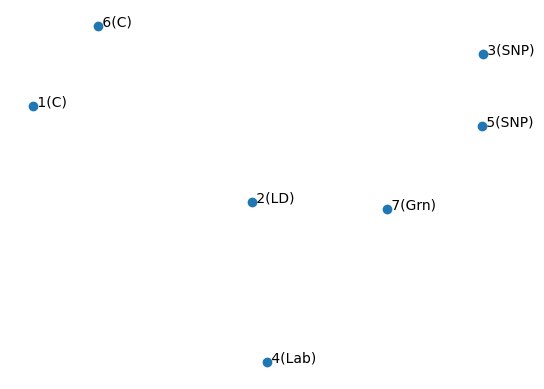

In [5]:
Candidate_MDS_plot(election, method = 'borda', party_names=party_names)

In [6]:
def Group_candidates(election, num_cands = 'Auto', method = 'succesive', trunc = None, link = 'avg'):
    """
    Prints the steps of repeatedly grouping candidates via agglomerative clustering
    using Candidate_dist_matrix as the pairwise distances.

    Args
        election : dictionary matching ballots with weights.
        num_cands : the number of candidates.  Set to 'Auto' to ask the algorithm to determine it.
        method : one of {'successive', 'coappearances'}
        trunc : ignore all ballot positions after this point.
        link : one of {'min', 'avg', 'max'} for single, averaged or complete linkage clustering.
    """
    if num_cands == 'Auto':
        num_cands = max([item for ranking in election.keys() for item in ranking])
    M = Candidate_dist_matrix(election, num_cands, method = method, trunc = trunc)
    L = [{n} for n in range(1,num_cands+1)]
    print(L)
    while len(L)>1:
        best_val = np.infty
        best_pair = (np.nan,np.nan)
        for i in range(len(L)):
            for j in range(i+1,len(L)):
                comparisons = [M[x-1,y-1] for x in L[i] for y in L[j]]
                if link == 'avg':
                    score = np.mean(comparisons)
                elif link == 'max':
                    score = max(comparisons)
                elif link == 'min':
                    score = min(comparisons)
                else:
                    raise Exception("link must be 'avg' or 'min' or 'max'.")
                if score<best_val:
                    best_val = score
                    best_pair = (i,j)
        L = List_merge(L,best_pair[0],best_pair[1])
        print(L)

In [14]:
Group_candidates(election, method = 'mean_borda', link = 'avg')

[{1}, {2}, {3}, {4}, {5}, {6}, {7}]
[{1, 6}, {2}, {3}, {4}, {5}, {7}]
[{1, 6}, {2}, {3, 5}, {4}, {7}]
[{1, 4, 6}, {2}, {3, 5}, {7}]
[{1, 2, 4, 6}, {3, 5}, {7}]
[{1, 2, 4, 6, 7}, {3, 5}]
[{1, 2, 3, 4, 5, 6, 7}]
